In [ ]:
import os

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split




/home/tiggi/Documents/IU_projects/bitcoin_rec/cc_fraud_NMF/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[NMF From scratch](https://github.com/akcarsten/Non_Negative_Matrix_Factorization/blob/master/Non_Negative_Matrix_Factorization.ipynb)

In [2]:
datafolder = './data'
data = os.path.join(datafolder ,"3", "creditcard.csv")

if not os.path.exists(data):
    print('downloading data')
    # download data fro mkaggle and move it to the project folder
    path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
    print("Path to dataset files:", path)
    !mv $path $datafolder

In [3]:
df = pd.read_csv(data)
df.columns = [col.lower() for col in df.columns]
df.head()

,time,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v21,v22,v23,v24,v25,v26,v27,v28,amount,class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
#count classes
df.value_counts(df['class'])

class
0    284315
1       492
Name: count, dtype: int64

In [5]:
df.shape

(284807, 31)

In [6]:
non_fraud = df[df['class'] == 0]#.sample(10000)
fraud = df[df['class'] == 1]



In [7]:
sample = pd.concat([non_fraud.sample(1000),fraud]).copy().sample(frac=1).reset_index(drop=True)
x = sample.drop(['class'], axis=1).values
y = sample['class'].values

In [8]:
df

,time,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v21,v22,v23,v24,v25,v26,v27,v28,amount,class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [9]:
# set X train and y-train for only non-fraud data (class 0)
X_train, X_rest, y_train, y_rest = train_test_split(
    non_fraud.drop(['class'], axis=1).copy(), 
    non_fraud['class'], 
    test_size=0.8, 
    random_state=90, 
    shuffle=True)

In [10]:
X_train.shape

(56863, 30)

In [11]:
# # combine x_rest and y_rest with the fraud data and shuffle
X_rest['class'] = y_rest
val_data = pd.concat([X_rest, fraud]).sample(frac=1).reset_index(drop=True)
val_data

,time,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v21,v22,v23,v24,v25,v26,v27,v28,amount,class
0,156753.0,-0.301324,1.113710,-0.070717,-0.540810,0.079290,-1.174121,0.677560,0.213306,-0.226651,...,-0.213904,-0.574474,0.137812,0.039935,-0.461375,0.139804,0.120457,0.035775,9.03,0
1,63358.0,-0.741923,0.517476,2.222835,3.455207,-2.577983,2.434485,-0.779138,1.082400,0.651316,...,0.226512,1.023621,0.032632,0.238722,-0.513923,0.408054,-0.263078,-0.181923,198.75,0
2,42709.0,0.928655,-0.859765,1.003816,0.847560,-1.563493,-0.617940,-0.415120,-0.185794,-0.686641,...,-0.089910,0.053257,-0.152020,0.952594,0.433308,-0.278139,0.054458,0.072151,180.00,0
3,136268.0,-1.246316,-0.710075,0.972651,-2.021200,-0.159105,-0.494617,-0.683614,0.524524,-0.792431,...,0.602569,1.272428,-0.193498,0.725090,0.084397,-0.127325,0.004233,-0.038128,50.45,0
4,57249.0,-3.105691,2.403148,0.385620,-0.545802,-0.351955,-0.634894,0.510847,0.096391,1.724188,...,-0.553233,-0.710249,0.028912,0.008868,0.120588,0.062312,0.446450,0.353927,8.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227939,73312.0,0.924869,-1.348931,1.106491,-0.337189,-1.540627,0.419971,-1.006455,0.222460,-0.315256,...,0.205882,0.445216,-0.107800,0.289704,0.227010,-0.265287,0.042672,0.044393,173.66,0
227940,158224.0,-0.761115,0.752660,-0.588619,-0.735394,1.047455,-0.687428,1.506912,-0.430123,-0.116402,...,0.174627,0.730944,-0.031881,-0.358848,-0.429493,-0.423124,-0.276905,0.242209,49.99,0
227941,78380.0,1.259828,-1.203596,0.484158,-2.485314,-1.786057,-1.136630,-0.773229,-0.081767,1.246651,...,-0.280621,-0.136628,0.024666,0.580729,0.432923,-0.737627,0.112965,0.036775,44.98,0
227942,76558.0,0.913063,-0.399727,1.430611,1.383739,-1.260979,0.004453,-0.753447,0.253978,0.767216,...,0.344773,0.824657,-0.066200,0.395492,0.176380,-0.235755,0.067777,0.057527,100.82,0


In [12]:
# split test and val data: 
X_val, X_test, y_val, y_test = train_test_split(
    val_data.drop(['class'], axis=1).copy(), 
    val_data['class'], 
    test_size=0.1,          #  test apx. 5% of the total data
    random_state=90, 
    shuffle=True)


In [13]:
# scale the transaction amount

scaler = MinMaxScaler((0,1)).fit(X_train)#['amount'].values.reshape(-1, 1))
X_train = scaler.transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


In [14]:
# the fitting was done on X_train - therefore unseen values in x_val and test remained negatie
np.min(X_train), np.min(X_val), np.min(X_test)

(np.float64(0.0),
 np.float64(-1.258654390682006),
 np.float64(-0.46675672123746564))

for NMF we use the approximation $V = HW$, where W is the feature matrix and H contains the weights of the features. (similar to sklearn)

the cost function will be the distance between V and HW: $L(V,HW) = \| V-WH \|^2$ 

update qill be done with GD foe W and H.

The update function: 

$$H^{n+1}_{[i,j]} \leftarrow H^{n}_{[i,j]} \frac{((W^n)^T V))_{[i,j]}}{((W^n)^T W^n H^n)_{[i,j]}}$$
$$W^{n+1}_{[i,j]} \leftarrow W^{n}_{[i,j]} \frac{(V (H^{n+1})^T))_{[i,j]}}{(W^n H^{n+1} (H^{n+1})^T)_{[i,j]}}$$

source [paper (page 3)](https://papers.nips.cc/paper/2000/file/f9d1152547c0bde01830b7e8bd60024c-Paper.pdf) 

In [15]:
# the weight/features matrix update (similar to GD)
def update_H(W, H, V):
    numerator = W.T.dot(V)
    denominator = W.T.dot(W).dot(H) + 1e-10
    H = H*(numerator / denominator)
    return H

def update_W(W, H, V):
    numerator = V.dot(H.T)
    denominator = W.dot(H).dot(H.T) + 1e-10
    W = W*(numerator / denominator)
    return W

In [16]:
# initialize H and W: 
# initialize with random positive numbers and the dimensions for H and W fitting to the input V
# randomly choose 100 iterations and r=10
# the data contains negative values. 

def run_nmf(V, rank=10, iter=50):

    # initialize
    n, m = V.shape
    W = np.abs(np.random.rand( n, rank))
    H = np.abs(np.random.rand(rank, m))

    loss = []
    for i in range(iter):
        H = update_H(W,H,V)
        W = update_W(W,H,V)

        # loss by squared Frobenius norm        // change later to KL
        current_loss = np.sum((V - np.dot(W, H))**2)
        loss.append(current_loss)
    return W, H, loss

In [17]:
W, H, loss = run_nmf(X_train)

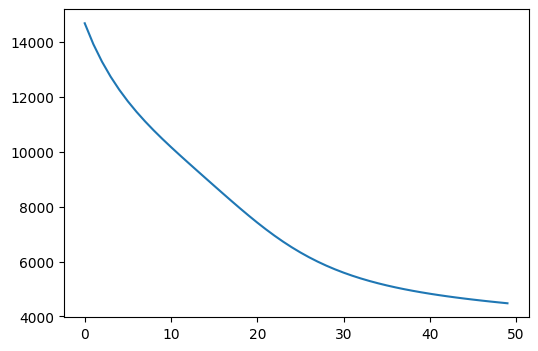

In [18]:
fig, ax = plt.subplots(figsize= [6,4])
ax.plot(loss)
plt.show()

In [19]:
ranks = [50, 100, 200]
rank_results = {}

for rank in ranks:
    W, H, loss = run_nmf(X_train, rank=rank, iter=150)
    rank_results[f'rank: {rank}'] = {'loss': loss, 'W': W, 'H': H}



In [20]:
losses = [rank_results[key]['loss'] for key in list(rank_results.keys())]
len(losses)

3

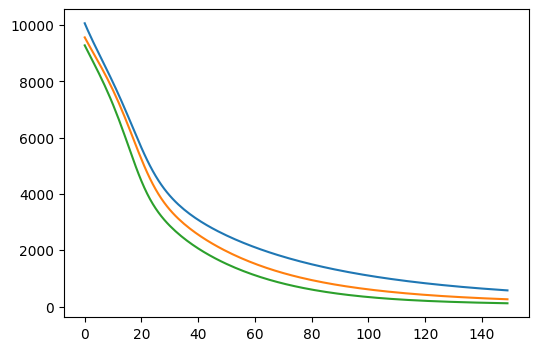

In [21]:
# plot loss: 
fig, ax = plt.subplots(figsize= [6,4])
for loss in losses:
    ax.plot(loss)
plt.show()

In [22]:
# optimize with rank=100
W, H, loss = run_nmf(X_train, rank=100, iter=120)

In [23]:
# Predict
def predict(V_test, H=H, iter=100):
    """
    V_test: New data (samples x features)
    H: The fixed basis (latent features) learned from Class 0 (rank x features [m])
    """
    n = V_test.shape[0]
    rank = H.shape[0]

    # initialize the weights matrix for recreation
    W_test = np.random.rand(n, rank)

    epsilon = 1e-9
    for i in range(iter):
        W_test = update_W(W_test, H, V_test)

    V_pred = W_test @ H

    sample_error = np.sqrt(np.sum((V_test - V_pred)**2, axis=1))
    return sample_error

In [24]:
val_err = predict(X_val)
val_scores = pd.DataFrame({'true_label':y_val, 'error': val_err})

In [25]:
val_scores

,true_label,error
196448,0,0.079683
130150,0,0.083224
184905,0,0.089767
57985,0,0.061111
57092,0,0.055781
...,...,...
75075,0,0.064578
203423,0,0.086784
136818,0,0.079299
166557,0,0.069667


In [26]:
val_scores.groupby('true_label')['error'].describe()

,count,mean,std,min,25%,50%,75%,max
true_label,,,,,,,,
0,204693.0,0.075151,0.038949,0.019366,0.054338,0.067533,0.086461,4.132768
1,456.0,0.546079,0.417605,0.032316,0.240572,0.413082,0.746842,1.796156


In [27]:
# normalize error: 
val_scores['norm_error'] = MinMaxScaler().fit_transform(val_err.reshape(-1,1)).flatten()
val_scores.groupby('true_label')['norm_error'].describe()

,count,mean,std,min,25%,50%,75%,max
true_label,,,,,,,,
0,204693.0,0.013562,0.009469,0.000000,0.008502,0.011710,0.016311,1.000000
1,456.0,0.128048,0.101523,0.003148,0.053777,0.095715,0.176855,0.431951


In [37]:
# threshold: 10%
threshold = 0.1

val_scores['tn'] = (val_scores['true_label'] == 0) & (val_scores['norm_error'] < threshold)
val_scores['fp'] = (val_scores['true_label'] == 0) & (val_scores['norm_error'] >= threshold)
val_scores['fn'] = (val_scores['true_label'] == 1) & (val_scores['norm_error'] < threshold)
val_scores['tp'] = (val_scores['true_label'] == 1) & (val_scores['norm_error'] >= threshold)

In [38]:
val_scores

,true_label,error,norm_error,tn,fp,fn,tp
196448,0,0.079683,0.014663,True,False,False,False
130150,0,0.083224,0.015524,True,False,False,False
184905,0,0.089767,0.017115,True,False,False,False
57985,0,0.061111,0.010148,True,False,False,False
57092,0,0.055781,0.008853,True,False,False,False
...,...,...,...,...,...,...,...
75075,0,0.064578,0.010991,True,False,False,False
203423,0,0.086784,0.016390,True,False,False,False
136818,0,0.079299,0.014570,True,False,False,False
166557,0,0.069667,0.012229,True,False,False,False


In [39]:
val_scores.sum()

true_label       456.000000
error          15631.833691
norm_error      2834.349361
tn            204459.000000
fp               234.000000
fn               236.000000
tp               220.000000
dtype: float64

results with 80% of the dataset for training: 

true_label      394.000000

error          4470.562516
norm_error      943.617770

tn            56787.000000

fp               75.000000

fn              217.000000

tp              177.000000

dtype: float64

with 20% of the data as training data: 
true_label       456.000000
error          15631.833691
norm_error      2834.349361
tn            204459.000000
fp               234.000000
fn               236.000000
tp               220.000000
dtype: float64

## Open points
- which distance function to take? KL or Frobean? 
- val data has negative values. handle with minmax scaling, with adding abs values? 
- normalizing the error? 
- check: convergance issues
- initialization with NNSVD [paper](https://user.it.uu.se/~milga730/histo/before2011august/Boutsidis.pdf) and [review from 2021](https://arxiv.org/pdf/2109.03874)